#  1. Environment Setup

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True


# 2. Load Dataset

In [18]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion", "unsplit")

dataset = pd.DataFrame(dataset)

In [19]:
print(dataset.shape, dataset.shape, dataset.shape)
dataset.head()

(416809, 1) (416809, 1) (416809, 1)


,train
0,{'text': 'i feel awful about it too because it...
1,"{'text': 'im alone i feel awful', 'label': 0}"
2,{'text': 'ive probably mentioned this before b...
3,{'text': 'i was feeling a little low few days ...
4,{'text': 'i beleive that i am much more sensit...


text: a string feature.

label: sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5).

In [20]:
df = pd.DataFrame()
df["text"] = dataset['train'].apply(lambda x: x['text'])
df["label"] = dataset['train'].apply(lambda x: x['label'])

label_map = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
df['emotion'] = df['label'].map(label_map)


df.head()

,text,label,emotion
0,i feel awful about it too because it s my job ...,0,sadness
1,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i reall...,1,joy
3,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to oth...,2,love


# EDA

### Class Distribution

In [21]:
print(df['emotion'].value_counts())

emotion
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64


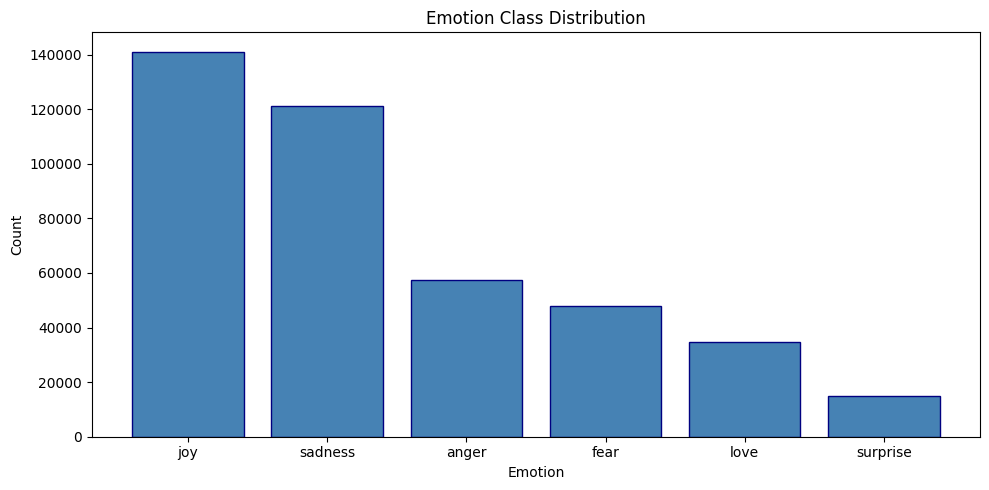

In [22]:
plt.figure(figsize=(10, 5))
counts = df['emotion'].value_counts()
plt.bar(counts.index, counts.values, color='steelblue', edgecolor='navy')
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Text Length Analysis

count    416809.000000
mean         19.211015
std          11.051049
min           1.000000
25%          11.000000
50%          17.000000
75%          25.000000
95%          41.000000
max         178.000000
Name: word_count, dtype: float64


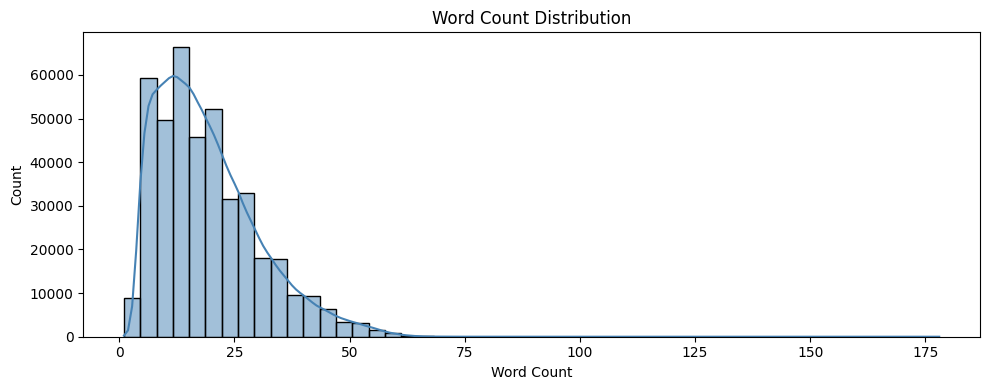

In [23]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print(df['word_count'].describe(percentiles = [.25, .5, .75 , .95]))

plt.figure(figsize=(10, 4))
sns.histplot(df['word_count'], bins=50, kde=True, color='steelblue')
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.tight_layout()
plt.show()

### Avg text length per emotion

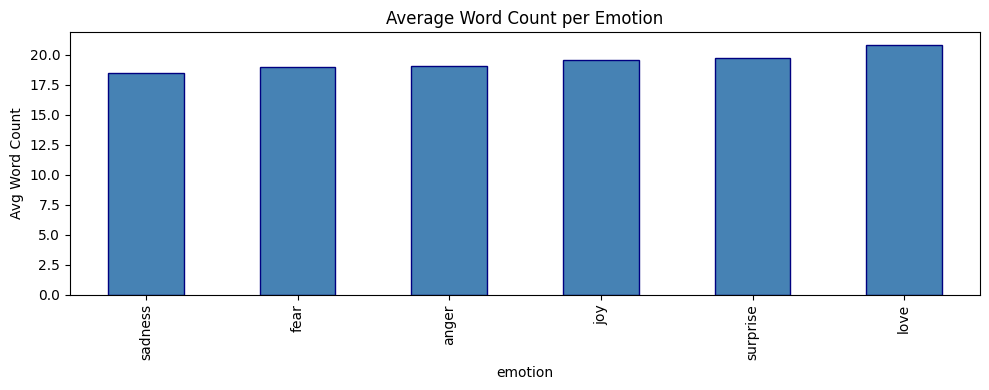

In [24]:
df.groupby('emotion')['word_count'].mean().sort_values().plot(
    kind='bar', figsize=(10, 4), color='steelblue', edgecolor='navy'
)
plt.title('Average Word Count per Emotion')
plt.ylabel('Avg Word Count')
plt.tight_layout()
plt.show()

# Preprocessing

### Train/Val/Test Split

In [25]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'] , shuffle=True)
df_val, df_test   = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['label'] , shuffle=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 333447 | Val: 41681 | Test: 41681


### Compute Class Weights

In [26]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(6),
    y=df_train['label'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([0.5732, 0.4925, 2.0104, 1.2120, 1.4560, 4.6397])


### Tokenizer + Dataset Class

In [27]:

from transformers import AutoTokenizer
from torch.utils.data import Dataset

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 52

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts  = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = EmotionDataset(df_train['text'], df_train['label'], tokenizer, MAX_LEN)
val_dataset   = EmotionDataset(df_val['text'],   df_val['label'],   tokenizer, MAX_LEN)
test_dataset  = EmotionDataset(df_test['text'],  df_test['label'],  tokenizer, MAX_LEN)

print(f"Datasets ready. Sample: {train_dataset[0]}")

Datasets ready. Sample: {'input_ids': tensor([  101,  1045,  2514,  2061,  3294,  1998,  6171, 10439,  2890,  7405,
         6024,  2000,  2031,  2032,  1999,  2026,  2166,   102,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0]), 'label': tensor(1)}


### DataLoaders

In [28]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 5211 | Val batches: 652


# Load Model

In [29]:

from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6
)
model = model.to(device)

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use both T4s if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)

model = model.to(device)
print("Device:", device)
print("CUDA version:", torch.version.cuda)

Using 2 GPUs
Device: cuda
CUDA version: 12.8


### Optimizer + Scheduler + Loss

In [31]:
EPOCHS    = 4
LR        = 2e-5
PATIENCE  = 5

optimizer = AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
scheduler = get_scheduler("linear", optimizer=optimizer,
                          num_warmup_steps=int(0.1 * total_steps),
                          num_training_steps=total_steps)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

# Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=3, verbose=True):
        self.patience   = patience
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, val_f1):
        if self.best_score is None:
            self.best_score = val_f1

        elif val_f1 <= self.best_score:
            self.counter += 1
            print(f"  EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True

        else:
            self.best_score = val_f1
            self.counter    = 0

early_stopping = EarlyStopping(patience=PATIENCE)

#  Training Loop

In [32]:
from tqdm import tqdm  # progress bar

best_val_f1 = 0
history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
epoch_cnt = 0

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_loss = 0
    epoch_cnt += 1

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        

    avg_train_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # --- Validate ---
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_f1  = f1_score(all_labels, all_preds, average='macro')
    val_acc = accuracy_score(all_labels, all_preds)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\nEpoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        if isinstance(model, torch.nn.DataParallel):
            torch.save(model.module.state_dict(), 'best_emotion_model.pt')
        else:
            torch.save(model.state_dict(), 'best_emotion_model.pt')
        print("  ✓ Best model saved")

    # --- Early Stopping Check ---
    early_stopping(val_f1)
    if early_stopping.stop:
        print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1 Training: 100%|██████████| 5211/5211 [17:57<00:00,  4.84it/s]



Epoch 1 | Train Loss: 0.3060 | Val Acc: 0.9390 | Val F1: 0.9147
  ✓ Best model saved


Epoch 2 Training: 100%|██████████| 5211/5211 [17:56<00:00,  4.84it/s]



Epoch 2 | Train Loss: 0.1116 | Val Acc: 0.9412 | Val F1: 0.9169
  ✓ Best model saved


Epoch 3 Training: 100%|██████████| 5211/5211 [17:57<00:00,  4.84it/s]



Epoch 3 | Train Loss: 0.1035 | Val Acc: 0.9413 | Val F1: 0.9170
  ✓ Best model saved


Epoch 4 Training: 100%|██████████| 5211/5211 [17:53<00:00,  4.85it/s]



Epoch 4 | Train Loss: 0.0992 | Val Acc: 0.9419 | Val F1: 0.9177
  ✓ Best model saved


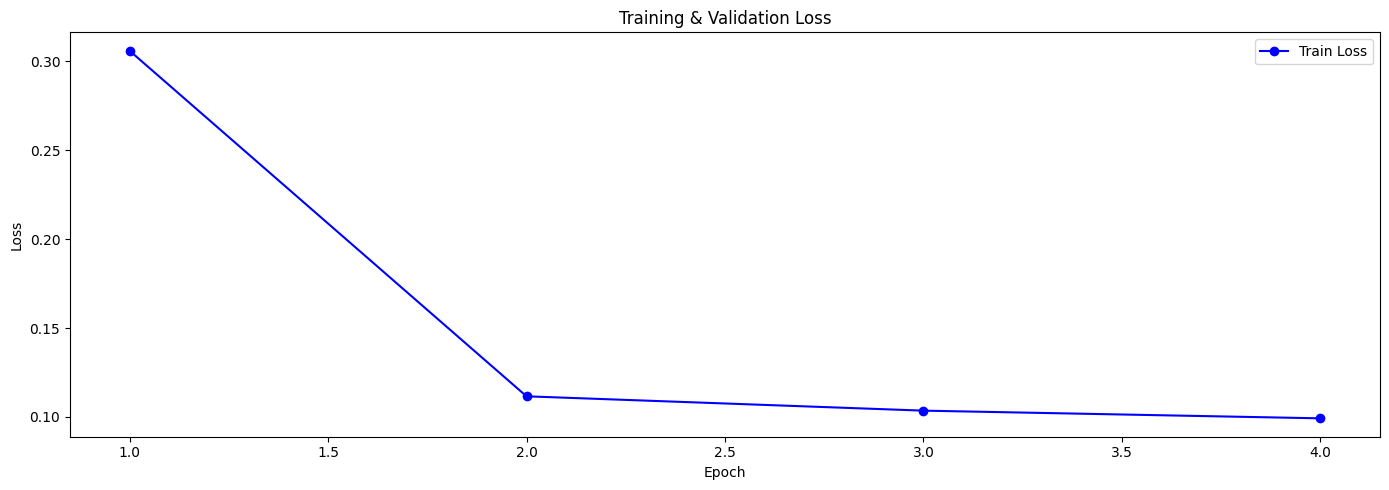

In [37]:
epochs_range = range(1, epoch_cnt + 1)

fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Loss
axes.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes.set_title('Training & Validation Loss')
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')
axes.legend()

plt.tight_layout()
plt.show()

## Final Evaluation on Test Set

Evaluating on Test Set: 100%|██████████| 652/652 [00:47<00:00, 13.64it/s]


              precision    recall  f1-score   support

     sadness       1.00      0.95      0.97     12119
         joy       1.00      0.91      0.95     14107
        love       0.77      1.00      0.87      3456
       anger       0.94      0.95      0.95      5731
        fear       0.90      0.91      0.90      4771
    surprise       0.73      1.00      0.84      1497

    accuracy                           0.94     41681
   macro avg       0.89      0.95      0.91     41681
weighted avg       0.95      0.94      0.94     41681



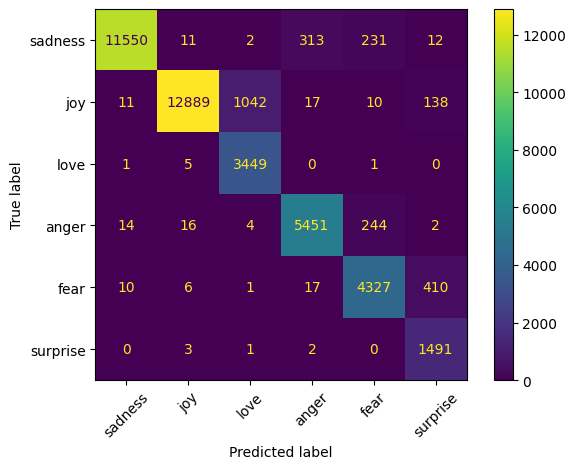

In [40]:
# Load state dict into the underlying model, not the DataParallel wrapper
if isinstance(model, torch.nn.DataParallel):
    model.module.load_state_dict(torch.load('best_emotion_model.pt'))
else:
    model.load_state_dict(torch.load('best_emotion_model.pt'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating on Test Set"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

print(classification_report(all_labels, all_preds, target_names=label_names))

# Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=label_names)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Model + Tokenizer

In [39]:

tokenizer.save_pretrained('emotion_model')

('emotion_model/tokenizer_config.json', 'emotion_model/tokenizer.json')

# Inference

In [43]:

def predict_emotion(text, model, tokenizer, device, max_len=64):
    label_map = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).squeeze()
        pred    = torch.argmax(probs).item()

    confidence = {label_map[i]: f"{probs[i].item()*100:.2f}%" for i in range(6)}

    print("="*40)
    print(f"Text       : {text}")
    print(f"Emotion    : {label_map[pred]}")
    print(f"Confidence : {dict(sorted(confidence.items(), key=lambda x: x[1], reverse=True))}")
    print("="*40)

    return label_map[pred]

# Test it
predict_emotion("what the fuck is going on this not good from you man", model, tokenizer, device)
predict_emotion("i just got graduated from the iti and this is the best thing happend this year", model, tokenizer, device)
predict_emotion("i feel like everything is dark, there is no color in my life any more", model, tokenizer, device)

Text       : what the fuck is going on this not good from you man
Emotion    : anger
Confidence : {'anger': '89.43%', 'fear': '8.08%', 'sadness': '2.29%', 'joy': '0.15%', 'love': '0.02%', 'surprise': '0.02%'}
Text       : i just got graduated from the iti and this is the best thing happend this year
Emotion    : joy
Confidence : {'joy': '99.81%', 'sadness': '0.07%', 'fear': '0.06%', 'anger': '0.05%', 'surprise': '0.01%', 'love': '0.00%'}
Text       : i feel like everything is dark, there is no color in my life any more
Emotion    : fear
Confidence : {'fear': '94.38%', 'surprise': '5.08%', 'sadness': '0.45%', 'love': '0.05%', 'joy': '0.03%', 'anger': '0.01%'}


'fear'